# Trabajo Practico Integrador: Analisis de Desempeno y Gestion de Estudiantes
**Materia:** Analisis de Datos Inicial
**Carrera:** Tecnicatura Universitaria en Programacion (TUP)

**Integrantes del grupo:**
1. [Gianfranco Guzman]
2. [Alexander Filchel]
3. [Bruno Racconto]


## Hito 1: Eleccion y Planteo

**Dataset elegido:** `student_learning_trajectory.csv`

Este conjunto de datos simula el comportamiento de aprendizaje y el rendimiento
de los estudiantes durante un semestre (16 semanas). Cada fila representa a un
estudiante en una semana, capturando sus habitos de estudio, factores de estilo
de vida y resultados academicos.

Es sintetico, generado artificialmente usando reglas realistas y variaciones aleatorias.

**Fuente:** https://www.kaggle.com/datasets/mabubakrsiddiq/students-learning-trajectory

**Columnas / Articulos**
1. student_id - Identificador unico para cada estudiante.
2. semana - Numero de semana (1-16) del semestre.
3. horas_de_estudio - Horas dedicadas al estudio en una semana (0-10).
4. horas_de_sueño - Promedio de horas de sueño diarias (4-9).
5. stress_level - Nivel de estrés del estudiante (0-10).
6. tasa_de_asistencia - Fraccion de clases a las que se asiste (0-1).
7. screen_time_hours - Tiempo promedio diario frente a la pantalla (1-10 horas).
8. ingesta de cafeina - Tazas de cafe/te consumidas por dia (0-6).
9. learning_efficiency - Factor latente (0-1) de eficacia de estudio.
10. fatigo_index - Cansancio en funcion del estrés y el sueño.
11. Puntuacion del cuestionario: puntuacion semanal (0-100).
12. assignment_score - Puntuacion semanal de tareas (0-100).
13. performance_index - Rendimiento semanal general.

**Objetivos del Analisis (Preguntas a responder):**
1. Que patrones en el comportamiento semanal anticipan una caida en el rendimiento academico?
2. Como impactan el estrés y el sueño en el rendimiento a lo largo del semestre?
3. Se pueden identificar perfiles de estudiantes segun su trayectoria de aprendizaje?


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


---
## Hito 2: Limpieza y Preparacion

Carga de datos y auditoria inicial para entender el estado del dataset.
Luego se aplican las tecnicas de limpieza necesarias.


In [21]:
# Carga de datos
df = pd.read_csv('data/raw/student_learning_trajectory_noisy.csv')

# Auditoria inicial
print("--- Primeras 5 filas ---")
display(df.head())

print("\n--- Informacion del dataset ---")
df.info()

print("\n--- Valores nulos por columna ---")
print(df.isnull().sum())

print(f"\nFilas duplicadas: {df.duplicated().sum()}")


--- Primeras 5 filas ---


,student_id,week,study_hours,sleep_hours,stress_level,attendance_rate,screen_time_hours,caffeine_intake,learning_efficiency,fatigue_index,quiz_score,assignment_score,performance_index
0,213.0,3.0,7.299494919461844,6.222351,0.655203,0.847996,8.285201,0.0,0.482721,0.324737,68.165919,111.799083,94.345817
1,374.0,8.0,9.81266716799645,6.934392,7.225068,NaN,NaN,1.0,0.696077,0.744376,69.951208,126.120601,103.652844
2,110.0,12.0,9.959409996857094,7.928768,4.123843,0.922061,1.000000,2.0,0.554851,0.412384,65.295440,123.549098,100.247635
3,424.0,13.0,9.464955714745257,4.207392,4.549566,0.835774,3.173800,4.0,0.668728,1.385826,65.775280,115.636119,95.691783
4,550.0,3.0,10.0,6.313722,4.377699,0.906354,1.000000,1.0,0.388347,0.666529,71.392775,115.719855,97.989023



--- Informacion del dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 10265 entries, 0 to 10264
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           9985 non-null   float64
 1   week                 9973 non-null   float64
 2   study_hours          9983 non-null   str    
 3   sleep_hours          9983 non-null   float64
 4   stress_level         9955 non-null   float64
 5   attendance_rate      9987 non-null   float64
 6   screen_time_hours    9984 non-null   float64
 7   caffeine_intake      9937 non-null   float64
 8   learning_efficiency  9930 non-null   float64
 9   fatigue_index        9966 non-null   float64
 10  quiz_score           9928 non-null   float64
 11  assignment_score     9951 non-null   float64
 12  performance_index    9976 non-null   float64
dtypes: float64(12), str(1)
memory usage: 1.0 MB

--- Valores nulos por columna ---
student_id             280
week    

### Aplicacion de Limpieza

Procesamiento de nulos, correccion de tipos, feature engineering y validacion final.


In [22]:
df = df.copy()

# Normalizar nombres de columnas
df.columns = df.columns.str.lower().str.strip()

# Eliminar duplicados
df = df.drop_duplicates()

# Corregir tipos
df["study_hours"] = pd.to_numeric(df["study_hours"], errors="coerce")
df["student_id"] = df["student_id"].astype("Int64").astype(str)
df["week"] = df["week"].astype("Int64")

# Manejo de nulos
df = df.dropna(subset=["student_id", "week", "performance_index"])

cols_numericas = [
    "study_hours", "sleep_hours", "stress_level", "screen_time_hours",
    "caffeine_intake", "learning_efficiency", "fatigue_index",
    "quiz_score", "assignment_score"
]
for col in cols_numericas:
    if col == "assignment_score":
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].median())

# Corregir valores fuera de rango
df["study_hours"] = df["study_hours"].clip(0, 12)
df["sleep_hours"] = df["sleep_hours"].clip(3, 10)
df["stress_level"] = df["stress_level"].clip(0, 10)
df["attendance_rate"] = df["attendance_rate"].clip(0, 1)
df["screen_time_hours"] = df["screen_time_hours"].clip(0, 12)
df["caffeine_intake"] = df["caffeine_intake"].clip(0, 6)
df["quiz_score"] = df["quiz_score"].clip(0, 100)
df["assignment_score"] = df["assignment_score"].clip(80, 110)

# Ruido controlado en assignment_score
import numpy as np
np.random.seed(42)
df["assignment_score"] = df["assignment_score"] + np.random.normal(0, 2, len(df))
df["assignment_score"] = df["assignment_score"].clip(80, 110)

# Filtrar asistencia fuera de rango
df = df[df["attendance_rate"].between(0, 1)]

# Ordenar por estudiante y semana
df = df.sort_values(["student_id", "week"])
df = df.reset_index(drop=True)

# FEATURE ENGINEERING
# Indice de constancia
df["constancy_index"] = df["study_hours"] * df["attendance_rate"]
# Fatiga real
df["real_fatigue"] = df["stress_level"] / (df["sleep_hours"] + 1)
# Riesgo academico (fatiga alta, poco sueño, estrés elevado)
df["risk_level"] = (
    (df["real_fatigue"] > 0.9) &
    (df["sleep_hours"] < 6.3) &
    (df["stress_level"] > 6.8)
).astype(int)
# Rendimiento ajustado por horas de estudio
df["adjusted_performance"] = df["performance_index"] / (df["study_hours"] + 1)
# Consumo digital excesivo
df["high_screen_time"] = (df["screen_time_hours"] > 7).astype(int)
# Perfil de estudiante por cuartiles de rendimiento
q1 = df["performance_index"].quantile(0.25)
q2 = df["performance_index"].quantile(0.50)
q3 = df["performance_index"].quantile(0.75)

def categorizar_perfil(row):
    if row["performance_index"] >= q3:
        return "Excelente"
    elif row["performance_index"] >= q2:
        return "Alto"
    elif row["performance_index"] >= q1:
        return "Medio"
    else:
        return "Bajo"

df["student_profile"] = df.apply(categorizar_perfil, axis=1).astype("category")
df["performance_index"] = df["performance_index"].clip(0, 110)

# Validacion final
print("\nColumnas:", df.columns.tolist())
print("\nDistribucion de riesgo:\n", df["risk_level"].value_counts())
print("\nPerfiles:\n", df["student_profile"].value_counts())
print("\nShape:", df.shape)
print("\nNulos restantes:\n", df.isnull().sum())
print("\nTipos:\n", df.dtypes)
print("\nResumen estadistico:\n", df.describe())



Columnas: ['student_id', 'week', 'study_hours', 'sleep_hours', 'stress_level', 'attendance_rate', 'screen_time_hours', 'caffeine_intake', 'learning_efficiency', 'fatigue_index', 'quiz_score', 'assignment_score', 'performance_index', 'constancy_index', 'real_fatigue', 'risk_level', 'adjusted_performance', 'high_screen_time', 'student_profile']

Distribucion de riesgo:
 risk_level
0    8542
1     423
Name: count, dtype: int64

Perfiles:
 student_profile
Excelente    2242
Alto         2241
Bajo         2241
Medio        2241
Name: count, dtype: int64

Shape: (8965, 19)

Nulos restantes:
 student_id              0
week                    0
study_hours             0
sleep_hours             0
stress_level            0
attendance_rate         0
screen_time_hours       0
caffeine_intake         0
learning_efficiency     0
fatigue_index           0
quiz_score              0
assignment_score        0
performance_index       0
constancy_index         0
real_fatigue            0
risk_level       

In [23]:
df.describe()


,week,study_hours,sleep_hours,stress_level,attendance_rate,screen_time_hours,caffeine_intake,learning_efficiency,fatigue_index,quiz_score,assignment_score,performance_index,constancy_index,real_fatigue,risk_level,adjusted_performance,high_screen_time
count,8965.0,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000,8965.000000
mean,8.507752,8.993775,6.894704,5.131182,0.847158,5.031178,1.998996,0.568831,0.636708,69.663952,108.849731,99.902696,7.619441,0.666192,0.047183,10.090389,0.158617
std,4.603472,0.943560,1.113712,2.042525,0.094524,1.921747,1.379513,0.105279,0.273828,5.879075,1.947447,5.497158,1.173375,0.295274,0.212043,1.091134,0.365339
min,1.0,5.711843,3.000000,0.000000,0.455541,1.000000,0.000000,0.313860,0.000000,46.907906,89.193321,80.139398,3.394660,0.000000,0.000000,6.548896,0.000000
25%,5.0,8.381352,6.280678,3.784592,0.781592,3.731994,1.000000,0.493566,0.451832,65.773576,108.307287,96.162959,6.807478,0.475407,0.000000,9.362088,0.000000
50%,8.0,9.031444,6.954200,5.108543,0.849789,5.006536,2.000000,0.568604,0.610697,69.649489,109.803380,100.027420,7.610969,0.641073,0.000000,9.983099,0.000000
75%,12.0,9.705661,7.624120,6.422916,0.917370,6.353011,3.000000,0.642896,0.797276,73.535496,110.000000,103.916791,8.394727,0.826441,0.000000,10.725506,0.000000
max,16.0,12.000000,9.000000,10.000000,1.000000,10.000000,6.000000,0.834974,1.922418,89.661750,110.000000,110.000000,12.000000,2.500000,1.000000,15.572390,1.000000


---
## Hito 3: Analisis y Visualizacion

Exploracion visual de los datos para responder las preguntas planteadas en el Hito 1.


### Visualizacion 1: Distribucion del rendimiento general

Histograma con curva de densidad que muestra como se distribuye el indice de rendimiento
global de todos los estudiantes.


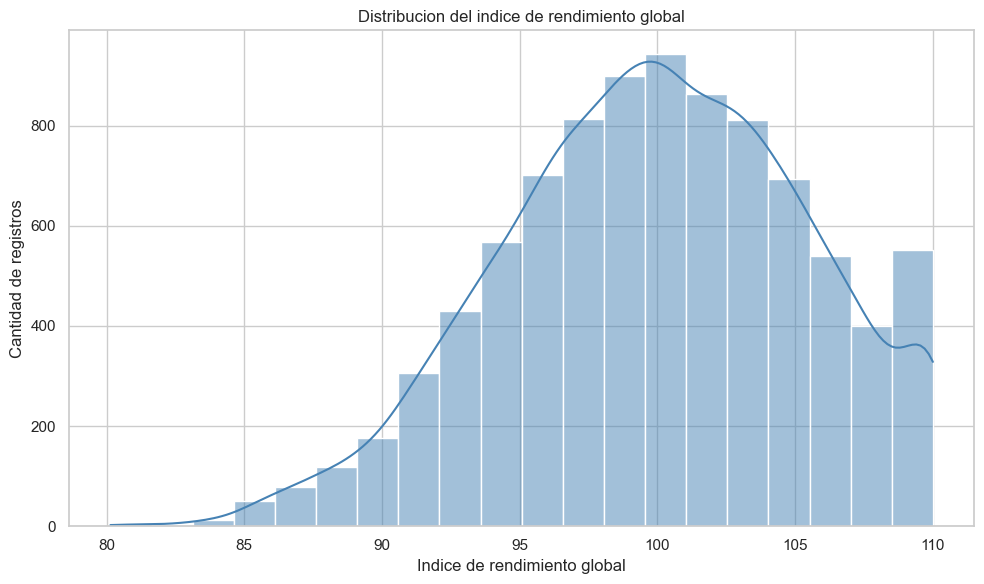

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df["performance_index"], bins=20, kde=True, color="steelblue")
plt.title("Distribucion del indice de rendimiento global")
plt.xlabel("Indice de rendimiento global")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()


**Conclusion V1:** La distribucion del indice de rendimiento global (combinacion de
examenes semanales y tareas, escala 0-110) esta concentrada en valores medios-altos.
La mediana ronda 100 y el rango intercuartilico abarca de 96 a 104, lo que indica que
la mayoria de los estudiantes mantiene un rendimiento estable. Los casos con valores
extremos (muy bajos o muy altos) son minoritarios, y es en esos donde conviene
focalizar la intervencion.


### Visualizacion 2: Estrés vs Rendimiento

Diagrama de dispersion que relaciona el nivel de estrés con el indice de rendimiento global.


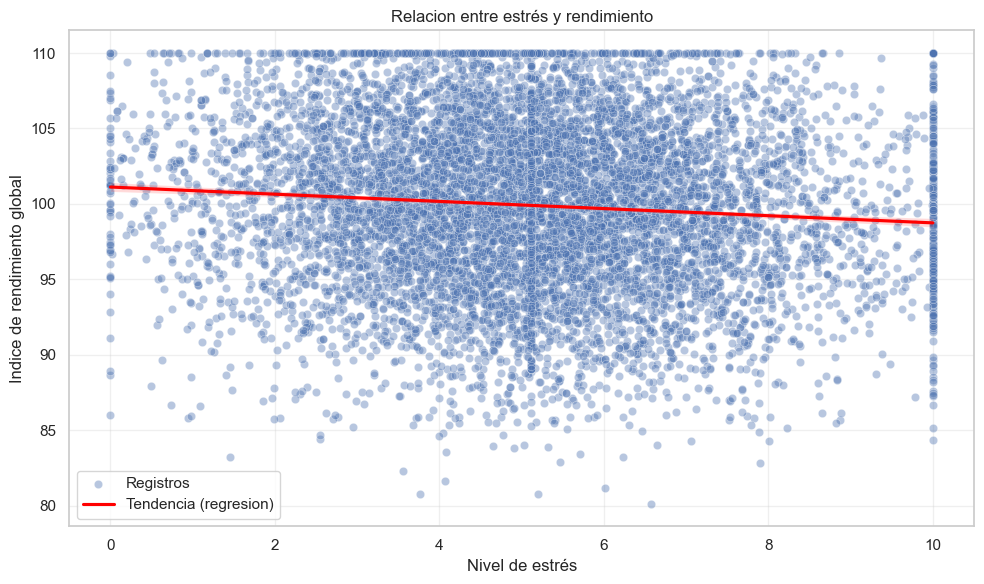

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="stress_level", y="performance_index",
                alpha=0.4, label="Registros")
sns.regplot(data=df, x="stress_level", y="performance_index",
            scatter=False, color="red", label="Tendencia (regresion)")
plt.title("Relacion entre estrés y rendimiento")
plt.xlabel("Nivel de estrés")
plt.ylabel("Indice de rendimiento global")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Conclusion V2:** Se observa una tendencia negativa clara entre el nivel de estrés
y el indice de rendimiento global: a mayor estrés, el rendimiento tiende a descender.
Aunque existe dispersion (no todos los estudiantes con estrés alto rinden mal), la
pendiente de la recta de regresion sugiere que el estrés sostenido en el tiempo
deteriora el desempeno academico.


### Visualizacion 3: Sueño vs Rendimiento

Diagrama de dispersion que relaciona las horas de sueño con el indice de rendimiento global.


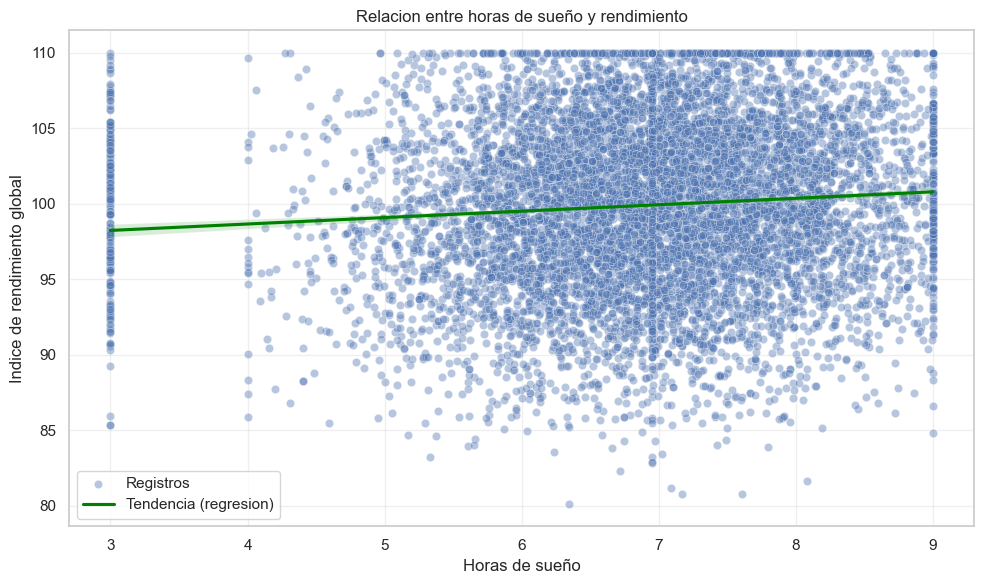

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="sleep_hours", y="performance_index",
                alpha=0.4, label="Registros")
sns.regplot(data=df, x="sleep_hours", y="performance_index",
            scatter=False, color="green", label="Tendencia (regresion)")
plt.title("Relacion entre horas de sueño y rendimiento")
plt.xlabel("Horas de sueño")
plt.ylabel("Indice de rendimiento global")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Conclusion V3:** La relacion entre las horas de sueño y el indice de rendimiento
global es positiva: mas horas de descanso se asocian con mejor desempeno, especialmente
en el rango de 6 a 8 horas diarias. Por debajo de 6 horas se concentra la mayoria de
los casos de bajo rendimiento, lo que indica que el descanso insuficiente impacta
negativamente en el desempeno.


### Visualizacion 4: Distribucion del rendimiento por perfil

Boxplot que compara la distribucion del indice de rendimiento global segmentado
por perfil de estudiante (Bajo, Medio, Alto, Excelente).


C:\Users\Gian\AppData\Local\Temp\ipykernel_24492\1700035090.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="student_profile",


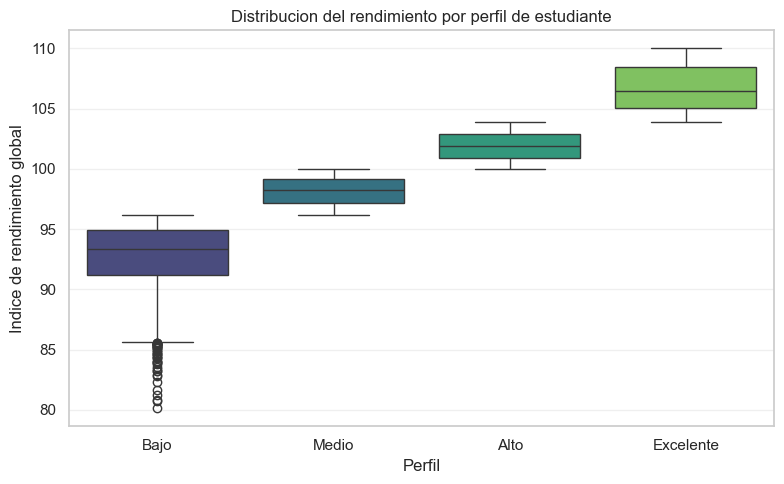

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="student_profile",
            order=["Bajo", "Medio", "Alto", "Excelente"],
            y="performance_index", hue="student_profile", palette="viridis", legend=False)
plt.title("Distribucion del rendimiento por perfil de estudiante")
plt.xlabel("Perfil")
plt.ylabel("Indice de rendimiento global")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


**Conclusion V4:** El boxplot confirma que la segmentacion por cuartiles del indice
de rendimiento global genera cuatro grupos con distribuciones claramente diferenciadas.
Los perfiles Bajo y Medio presentan mayor dispersion y valores atipicos (outliers)
visibles por debajo del bigote inferior, mientras que Excelente y Alto son mas
homogeneos. Esto valida que los perfiles capturan diferencias reales y no son una
clasificacion artificial. Responde a la pregunta 3: si, se distinguen perfiles de
estudiantes y se pueden segmentar para estrategias diferenciadas.


### Visualizacion 5: Evolucion semanal de estrés y sueño

Grafico de lineas que muestra la evolucion del nivel de estrés y las horas de sueño
promedio a lo largo del semestre.


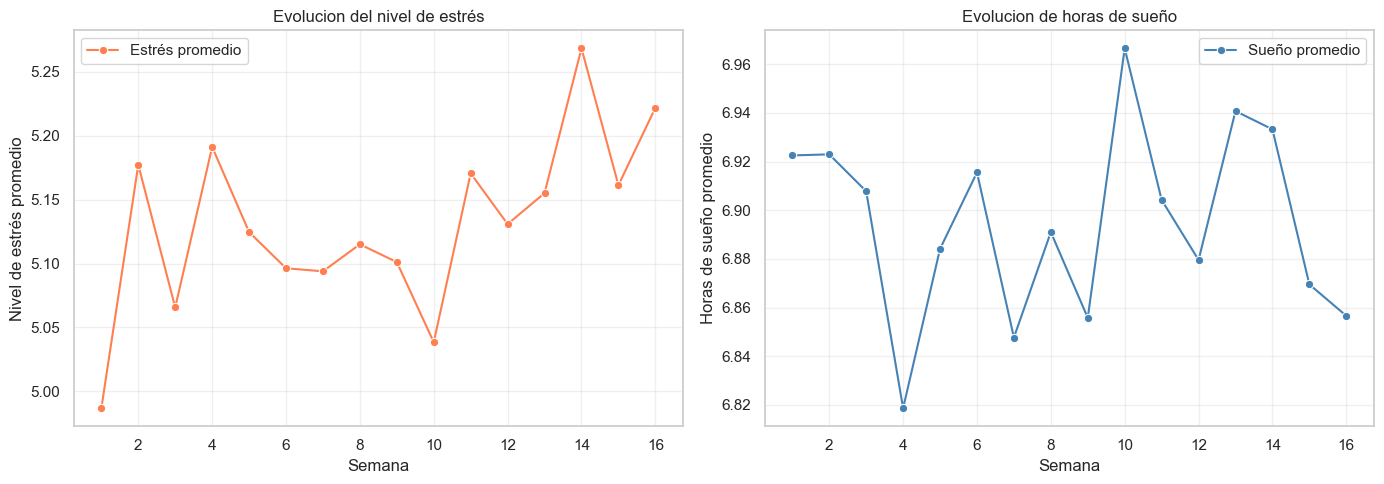

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=df, x="week", y="stress_level", errorbar=None,
             marker="o", color="coral", label="Estrés promedio", ax=axes[0])
axes[0].set_title("Evolucion del nivel de estrés")
axes[0].set_xlabel("Semana")
axes[0].set_ylabel("Nivel de estrés promedio")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

sns.lineplot(data=df, x="week", y="sleep_hours", errorbar=None,
             marker="o", color="steelblue", label="Sueño promedio", ax=axes[1])
axes[1].set_title("Evolucion de horas de sueño")
axes[1].set_xlabel("Semana")
axes[1].set_ylabel("Horas de sueño promedio")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


**Conclusion V5:** El nivel de estrés promedio aumenta progresivamente hacia la
mitad del semestre (semanas 7-9) y se mantiene elevado, coincidiendo con periodos
de mayor exigencia academica (parciales, entregas). Simultaneamente, las horas de
sueño muestran una leve tendencia decreciente. Ambos patrones son factores que,
cuando se combinan, anteceden caidas en el indice de rendimiento global. Esto
responde a la pregunta 1: el aumento sostenido de estrés y la reduccion de sueño
son indicadores tempranos de riesgo academico.


---
## Hito 4: Dashboard Interactivo
https://eif7f7yzt9uznrvl8ngwcj.streamlit.app
---


---
## Hito 5: Informe de Gestion

*(Fuera del alcance de esta entrega -- incluido como referencia)*
---
